# BEE 4750 Homework 3: Dissolved Oxygen and Monte Carlo

**Name**: Adrián Cardona Young

**ID**: alc354

> **Due Date**
>
> Thursday, 10/16/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to implement a model for dissolved oxygen in a
    river with multiple waste releases and use this to develop a
    strategy to ensure regulatory compliance.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [36]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `c:\Users\adric\OneDrive - Cornell University\Documents\3. Env Sys Analysis\HWs\hw3-adrianhw3`


In [37]:
using Random
using Plots
using LaTeXStrings
using Distributions
using Plots.PlotMeasures

## Problems (Total: 30 Points)

### Problem 1 (30 points)

A river which flows at 6 km/d is receiving waste discharges from two
sources which are 15 km apart. The oxygen reaeration rate is 0.55
day<sup>-1</sup>, and the decay rates of CBOD and NBOD are are 0.35 and
0.25 day<sup>-1</sup>, respectively. The river’s saturated dissolved
oxygen concentration is 10m g/L.

If the characteristics of the river inflow and waste discharges are
given in <a href="#tbl-river" class="quarto-xref">Table 1</a>, write a
Julia model to compute the dissolved oxygen concentration from the first
wastewater discharge to an arbitrary distance `d` km downstream. Use
your model to compute the minimum dissolved oxygen concentration up to
50 km downstream and how far downriver this maximum occurs.

| Parameter | River Inflow | Waste Stream 1 | Waste Stream 2 |
|:--:|---:|---:|---:|
| Inflow | 100,000 m<sup>3</sup>/d | 10,000 m<sup>3</sup>/d | 15,000 m<sup>3</sup>/d |
| DO Concentration | 7.5 mg/L | 5 mg/L | 5 mg/L |
| CBOD | 5 mg/L | 50 mg/L | 45 mg/L |
| NBOD | 5 mg/L | 35 mg/L | 35 mg/L |

Table 1: River inflow and waste stream characteristics for Problem 1.

### Problem 1.1

Implement the Streeter-Phelps (analytic) solution for the dissolved
oxygen concentration. Plot the dissolved oxygen concentration from the
first waste stream to 50 km downriver. What is the minimum value in
mg/L?

In [38]:
function Mix(q1, c1, q2, c2)
    #Function returns concentration of stream after mixing
    return (q1*c1 + q2*c2)/(q1+q2)
end

function alpha1(ka, x, u)
    return exp(-ka*x/u)
end

function alpha2(ka, kc, x, u)
    return (kc/(ka - kc))*(exp(-kc*x/u) - exp(-ka*x/u))
end

function alpha3(ka, kn, x, u)
    return (kn/(ka - kn))*(exp(-kn*x/u) - exp(-ka*x/u))
end


alpha3 (generic function with 1 method)

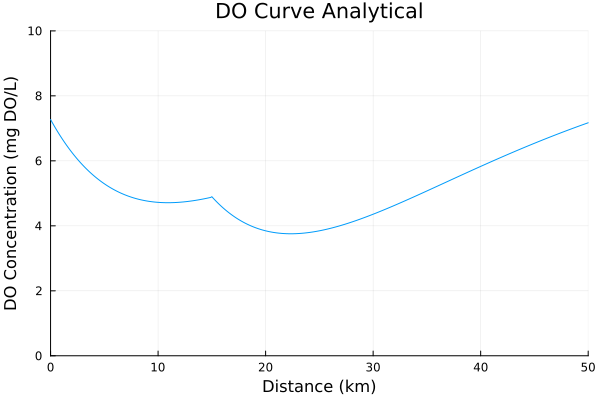

In [39]:
#Setting variables:
u = 6000 #m/d

ka = 0.55 #/day
kc = 0.35 #/day
kn = 0.25 #/day

cs = 10 #mg DO/L


#Spatial setup
x = collect(range(0, 50000, 501))

#First discharge mixing results:
#DO
DO_1 = Mix(100_000, 7.5, 10_000, 5);
CBOD_1 = Mix(100_000, 5, 10_000, 50);
NBOD_1 = Mix(100_000, 5, 10_000, 35);

DO = zeros(501)
DO[1] = DO_1

qnew = 100_000 + 10_000

#Stream feeding into second discharge:
for i in 1:151
    a1 = alpha1(ka, x[i], u)
    a2 = alpha2(ka, kc, x[i], u)
    a3 = alpha3(ka, kn, x[i], u)
    DO[i] = cs*(1-a1) + DO[1]*a1 - CBOD_1*a2 - NBOD_1*a3
end

CBOD_end1 = CBOD_1*exp(-kc*15000/u)
NBOD_end1 = NBOD_1*exp(-kn*15000/u)

#Second discharge mixing results:
DO_secondmix = Mix(qnew, DO[151], 15_000, 5)
DO[151] = DO_secondmix
CBOD_2 = Mix(qnew, CBOD_end1, 15_000, 45)
NBOD_2 = Mix(qnew, NBOD_end1, 15_000, 35)

for i in 151:501
    dist = x[i] - x[151]
    a1 = alpha1(ka, dist, u)
    a2 = alpha2(ka, kc, dist, u)
    a3 = alpha3(ka, kn, dist, u)
    DO[i] = cs*(1-a1) + DO[151]*a1 - CBOD_2*a2 - NBOD_2*a3
end

p1 = plot(x, DO, title="DO Curve Analytical", xlabel="Distance (km)", ylabel="DO Concentration (mg DO/L)", xformatter=x->round(Int64, x/1000), xlims=(0, 50000), ylims=(0, 10), legend=:false)
display(p1)

### Problem 1.2

Implement a numerically-integrated (discretized) solution for the
dissolved oxygen concentration. Using a resolution of 0.5km, conduct a
simulation and plot the results on the same axis as the plot from
Problem 1.1. How has the minimum value changed? What do you attribute
this difference to (be specific about the source of the difference(s) in
terms of the simulation dynamics, not just that one is a numerical
approximation).

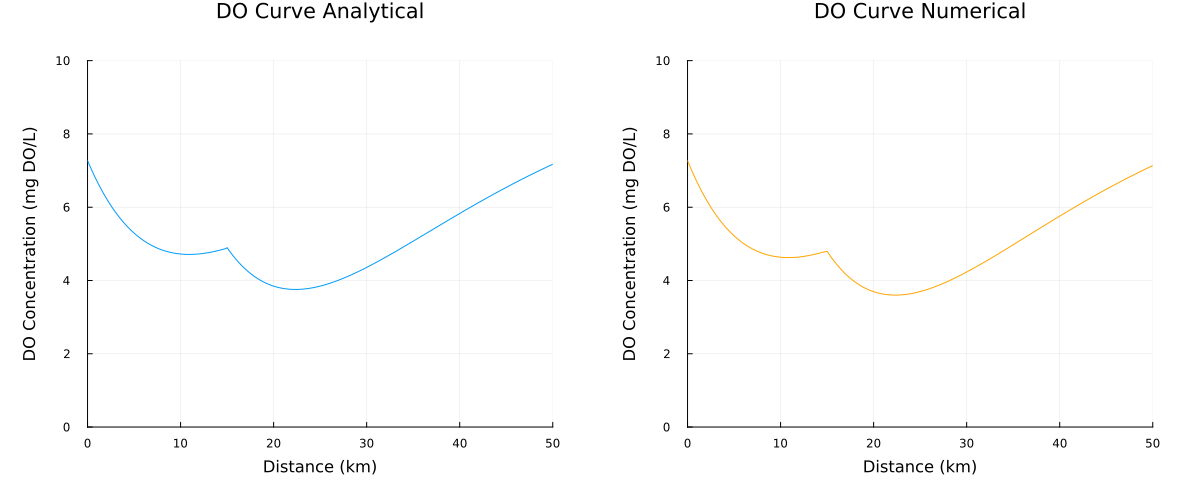

In [40]:
delta = 500 #m
x2 = collect(range(0, 50_000, 101));
DO2 = zeros(101);
CBOD2 = zeros(101);
NBOD2 = zeros(101);

#Initial mixing same
DO2[1] = DO_1;
CBOD2[1] = CBOD_1;
NBOD2[1] = NBOD_1;

#Numerical Methods Implementation
for i in 1:30
    DO2[i+1] = DO2[i] + (delta/u) * (ka*(cs - DO2[i]) - kc*CBOD2[i] - kn*NBOD2[i])
    CBOD2[i+1] = CBOD2[i]*exp(-kc*delta/u)
    NBOD2[i+1] = NBOD2[i]*exp(-kn*delta/u)
end

DO_2 = Mix(qnew, DO2[30], 15_000, 5)
DO2[31] = DO_2
CBOD2[31] = Mix(qnew, CBOD2[30], 15_000, 45)
NBOD2[31] = Mix(qnew, NBOD2[30], 15_000, 35)

for i in 31:100
    DO2[i+1] = DO2[i] + delta/u *(ka*(cs-DO2[i]) - kc*CBOD2[i] - kn*NBOD2[i])
    CBOD2[i+1] = CBOD2[i]*exp(-kc*delta/u)
    NBOD2[i+1] = NBOD2[i]*exp(-kn*delta/u)
end

p2 = plot(x2, DO2, title="DO Curve Numerical", xlabel="Distance (km)", ylabel="DO Concentration (mg DO/L)", xformatter=x->round(Int64, x/1000), xlims=(0, 50000), ylims=(0, 10), legend=:false, linecolor=:orange)

plot(p1, p2, layout=(1, 2), size=(1200, 500), margins=10mm)

### Problem 1.3

Using the analytic model, what is the minimum level of treatment (%
removal of organic waste; assume this is equivalent to the same level of
reduction of the CBOD and NBOD) for waste stream 1 that will ensure that
the dissolved oxygen concentration is in compliance with the 4 mg/L
standard along with a 5% margin of safety, assuming that waste stream 2
remains untreated? How about if only waste stream 2 is treated?

Stream only falls below 4.2 mg DO/L after second mixing. Therefore, calculate range of initial mixing values based on different level of treatment (0-100%) and then determine what curve looks like after second mixing.

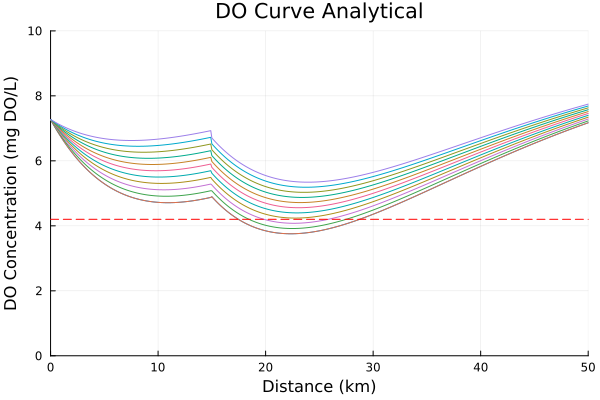

DOt =4.896480650455226DOt =5.077194774800183DOt =5.25790889914514DOt =5.4386230234900985DOt =5.619337147835054DOt =5.800051272180011DOt =5.980765396524967DOt =6.161479520869925DOt =6.3421936452148815DOt =6.522907769559838DOt =6.703621893904795[3.7557004698290717, 3.9171166733987874, 4.078030584018057, 4.238390951360605, 4.398149222541174, 4.557320369763282, 4.715850291937369, 4.873707274662821, 5.030895726256618, 5.187366825856503, 5.343053597156317]

In [41]:
minDO = 4*1.05
treats = collect(range(0, 1, 11))
DO_mins = zeros(11)

for t in 1:11
    DO_t = Mix(100_000, 7.5, 10_000, 5);
    CBOD_t = Mix(100_000, 5, 10_000, 50*(1-treats[t]));
    NBOD_t = Mix(100_000, 5, 10_000, 35*(1-treats[t]));

    DOt = zeros(501)
    DOt[1] = DO_t

    #Stream feeding into second discharge:
    for i in 1:151
        a1 = alpha1(ka, x[i], u)
        a2 = alpha2(ka, kc, x[i], u)
        a3 = alpha3(ka, kn, x[i], u)
        DOt[i] = cs*(1-a1) + DOt[1]*a1 - CBOD_t*a2 - NBOD_t*a3
    end

    CBOD_end1t = CBOD_t*exp(-kc*15000/u)
    NBOD_end1t = NBOD_t*exp(-kn*15000/u)

    #Second discharge mixing results:
    DO_secondmix_t = Mix(qnew, DOt[151], 15_000, 5)
    DOt[151] = DO_secondmix_t
    CBOD_2 = Mix(qnew, CBOD_end1t, 15_000, 45)
    NBOD_2 = Mix(qnew, NBOD_end1t, 15_000, 35)

    print("DOt =",DOt[151])

    for i in 151:501
        dist = x[i] - x[151]
        a1 = alpha1(ka, dist, u)
        a2 = alpha2(ka, kc, dist, u)
        a3 = alpha3(ka, kn, dist, u)
        DOt[i] = cs*(1-a1) + DOt[151]*a1 - CBOD_2*a2 - NBOD_2*a3
    end
    plot!(p1, x, DOt)
    DO_mins[t] = minimum(DOt)
end
hline!([minDO], linestyle=:dash, linecolor=:red)
display(p1)
print(DO_mins)

Per guidelines of minimum allowable dissolved oxygen and 5% margin of safety, DO has to remain above 4.2 mg DO/L. By running the simulation for ranges of treatments from 100% to 0%, shown in the plot above, it can be determined that the minimum treatment of only the first stream of 30% would maintain DO in the stream above the minimum.

### Problem 1.4

Suppose you are responsible for designing a waste treatment plan for
discharges into the river, with a regulatory mandate to keep the
dissolved oxygen concentration above 4 mg/L. Discuss whether you’d opt
to treat waste stream 2 alone or both waste streams equally. What other
information might you need to make a conclusion, if any?

Treating both streams requires a greater investment. While treating both may mean having to treat each one less than just choosing one, it would require a greater investment in infrastructure to be able to do this. Meanwhile, only treating one requires a greater extent of treatment of that discharge, but would require less overall infrastructure.

The plot in Problem 1.3 shows that achieving only 30% treatment in the first discharge would meet requirements. The curve after the second mixing is more or less the same for all scenarios, with the difference being how much it shifts up. Treating the second discharge would change the curve and the relative difference between the initial DO after mixing and the minimum. 

In [42]:
4.896480650455226 - 3.7557004698290717

1.1407801806261544

In [43]:
4.89 - 4.2

0.6899999999999995

In [44]:
0.69/1.14

0.6052631578947368

Since the drop in DO from second mix to minimum is 1.14 mg DO/L, and the second mix resulting concentration is 4.89 mg DO/L, to remain above 4.2, the drop would need to be reduced to ~0.69 mg DO/L, or reducing the drop by 40%. While this does not mean a treatment of 40%, it is likely that keeping levels above minimum would be easier by just treating the first discharge.

### Problem 1.5

Suppose that it is known that the DO concentrations at the river inflow
can vary according to a $\text{LogNormal}(2.0, 0.15)$ distribution.
Conduct a Monte Carlo simulation of the DO concentration in the river.
If you treat only waste stream 1 (based on your analysis from Problem
1.3), what is the expected probability and 95% confidence interval that
the river fails to comply with the regulatory standard of 4 mg/L? How
did you decide that your Monte Carlo sample size was sufficiently large?

In [45]:
n = 1000

function MC(ka, kc, kn, n)
    #Spatial setup
    x = collect(range(0, 50000, 501))
    DOMC_mins = zeros(n)

    lognorm = LogNormal(2.0, 0.15);
    init = rand(lognorm, n);

    for r in 1:n
        #First discharge mixing results:
        #DO
        DO_MC = Mix(100_000, init[r], 10_000, 5);
        CBOD_MC = Mix(100_000, 5*0.7, 10_000, 50);
        NBOD_MC = Mix(100_000, 5*0.7, 10_000, 35);

        DOMC = zeros(501)
        DOMC[1] = DO_MC

        #Stream feeding into second discharge:
        for i in 2:151
            a1 = alpha1(ka, x[i], u)
            a2 = alpha2(ka, kc, x[i], u)
            a3 = alpha3(ka, kn, x[i], u)
            DOMC[i] = cs*(1-a1) + DOMC[1]*a1 - CBOD_MC*a2 - NBOD_MC*a3
        end

        CBODMC_end1 = CBOD_MC*exp(-kc*15000/u)
        NBODMC_end1 = NBOD_MC*exp(-kn*15000/u)

        #Second discharge mixing results:
        DOMC_secondmix = Mix(qnew, DOMC[151], 15_000, 5)
        DOMC[151] = DOMC_secondmix
        CBODMC_2 = Mix(qnew, CBODMC_end1, 15_000, 45)
        NBODMC_2 = Mix(qnew, NBODMC_end1, 15_000, 35)

        for i in 151:500
            dist = x[i] - x[151]
            a1 = alpha1(ka, dist, u)
            a2 = alpha2(ka, kc, dist, u)
            a3 = alpha3(ka, kn, dist, u)
            DOMC[i] = cs*(1-a1) + DOMC[151]*a1 - CBODMC_2*a2 - NBODMC_2*a3
        end
        DOMC_mins[r] = minimum(DOMC)
    end
    return DOMC_mins
end

MC (generic function with 2 methods)

In [46]:
MC(ka, kc, kn, n)

1000-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

## References

List any external references consulted, including classmates.